In [1]:
import sys
import git
import pathlib

# Set up the PROJ_ROOT variable
PROJ_ROOT_PATH = pathlib.Path(git.Repo('.', search_parent_directories=True).working_tree_dir)
PROJ_ROOT =  str(PROJ_ROOT_PATH)
if PROJ_ROOT not in sys.path:
    sys.path.append(PROJ_ROOT)

# Explicitly add the current notebook's directory
CURRENT_DIR = str(pathlib.Path().absolute())
if CURRENT_DIR not in sys.path:
    sys.path.insert(0, CURRENT_DIR)

In [2]:
import numpy as np

In [3]:
diam = 0.254E-3 # AWG30
area = np.pi * (diam/2)**2

# raicu
l_50K = 0.3053
l_4K = 0.3155
l_Still = 0.2775
l_CP = 0.1965
l_MXC = 0.1965

T_50K = 40
T_4K = 3.5
T_RT = 297

# Thermal Conductivity

In [4]:
# https://www.lakeshore.com/products/categories/specification/temperature-products/cryogenic-accessories/cryogenic-wire
## Manganin - # 83-Cu, 13-Mn, 4-Ni
x_temp = np.array([0.1, 0.4, 1, 4, 10, 20, 80, 150, 300])
y_k = np.array([0.006, 0.02, 0.06, 0.5, 2, 3.3, 13, 16, 22])

In [5]:
# Perform linear fit (degree 1 for a straight line)
coefficients = np.polyfit(x_temp, y_k, 3)

In [6]:
# conductivity, K
def conductivity(x_temp):
    return np.polyval(coefficients, x_temp)

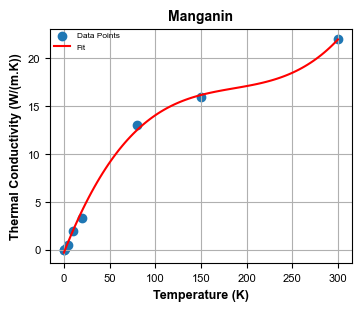

In [7]:
import matplotlib.pyplot as plt
from library.utils import fontstyle
title_font, axis_label_font, tick_label_font, legend_font, text_font = fontstyle

# IEEE TQE Guidelines
# Single column: 3.5" (wide) x 8.5" (height)
# Double column: 7.16" (wide) x 8.5" (height)
fig, ax = plt.subplots(nrows=1, 
                       ncols=1, 
                       figsize=(3.5, 3), 
                       constrained_layout=True)

# Plotting the results
x_vals = np.linspace(0,300,100)
y_vals = conductivity(x_vals)
ax.scatter(x_temp, y_k, label='Data Points')
ax.plot(x_vals, y_vals, color='red', label='Fit')
ax.set_title("Manganin", fontproperties=title_font)
ax.set_xlabel('Temperature (K)', fontproperties=axis_label_font)
ax.set_ylabel('Thermal Conductivity (W/(m.K))', fontproperties=axis_label_font)
for label in ax.get_yticklabels() :
        label.set_fontproperties(tick_label_font)

for label in ax.get_xticklabels() :
        label.set_fontproperties(tick_label_font)
    

ax.legend(prop=legend_font,
          frameon=False,
          borderaxespad=0.)

ax.grid(True)

plt.savefig(f"./mn_k.png",dpi=600)
# 1966powellr.wThermalConductivitySelected (united1966thermal)
plt.show()

In [8]:
from scipy.integrate import quad
import math

# Integrate f(x) from 50K to 4K
result, error = quad(conductivity, T_4K, T_50K)
print(f"The numerical result is {result:.6f} (+-{error:.10g})")

PHL_Mn_4K = result * (area/l_4K)
print(f"{PHL_Mn_4K=:.5e}")  # W/m

The numerical result is 157.842539 (+-1.75240421e-12)
PHL_Mn_4K=2.53502e-05


In [9]:
# Integrate f(x) from 300K to 50K
result, error = quad(conductivity, T_50K, T_RT)
print(f"The numerical result is {result:.6f} (+-{error:.10g})")

PHL_Mn_50K = result * (area/l_50K)
print(f"{PHL_Mn_50K=:.5e}")  # W/m

The numerical result is 4095.816396 (+-4.547269668e-11)
PHL_Mn_50K=6.79784e-04


# Electrical Resistivity

A key feature of Manganin is that its resistance changes very little with temperature even at cryogenic temperatures.

Hence we can model the resistivity from 4K to 50K using a linear fit using the values provided in https://www.lakeshore.com/products/categories/specification/temperature-products/cryogenic-accessories/cryogenic-wire

In [10]:
# https://www.lakeshore.com/products/categories/specification/temperature-products/cryogenic-accessories/cryogenic-wire
# Assuming 30 AWG
## Manganin - # 83-Cu, 13-Mn, 4-Ni
x_temp = np.array([4.2, 77, 305])
y_rho_data = np.array([8.64, 9.13, 9.69]) # Ohm/m for 30 AWG wire
y_rho = y_rho_data * area * 1E6

In [11]:
coefficients = np.polyfit(x_temp, y_rho, 2)

def manganin_rho(x_temp):
    return np.polyval(coefficients,x_temp) #1E-6ohm meter

In [12]:
# # Perform linear fit (degree 1 for a straight line)
# slope, intercept = np.polyfit(x_temp, y_rho, 1)

# # Linear Model for resistivity of Manganin
# def manganin_rho(T):
#     k = slope * T + intercept
#     return k # in 1e-8 ohm-meter

In [13]:
T_range = np.linspace(0, 310, 100)
rho_vals = manganin_rho(T_range) # Ohm/m for 30 AWG wire

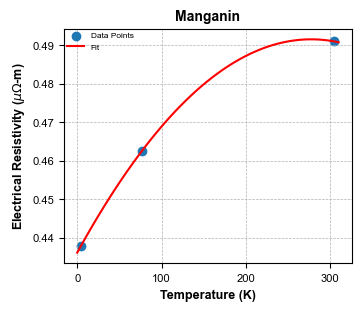

In [14]:
import matplotlib.pyplot as plt
from library.utils import fontstyle
title_font, axis_label_font, tick_label_font, legend_font, text_font = fontstyle

# IEEE TQE Guidelines
# Single column: 3.5" (wide) x 8.5" (height)
# Double column: 7.16" (wide) x 8.5" (height)
fig, ax = plt.subplots(nrows=1, 
                       ncols=1, 
                       figsize=(3.5, 3), 
                       constrained_layout=True)


ax.scatter(x_temp, y_rho, label='Data Points')
ax.plot(T_range, rho_vals, color='red', label='Fit')
# ax.set_xscale("log")
# ax.set_yscale("log")
# --- enable both major and minor grid lines ---
ax.grid(True, which="both", linestyle="--", linewidth=0.5)

ax.set_title("Manganin", fontproperties=title_font)
ax.set_xlabel('Temperature (K)', fontproperties=axis_label_font)
ax.set_ylabel(r'Electrical Resistivity ($\mu\Omega$-m)', fontproperties=axis_label_font)

for label in ax.get_yticklabels() :
        label.set_fontproperties(tick_label_font)

for label in ax.get_xticklabels() :
        label.set_fontproperties(tick_label_font)

ax.legend(prop=legend_font,
          frameon=False,
          borderaxespad=0.)
plt.savefig(f"./mn_rho.png",dpi=600)
#https://www.twire.co.jp/english/Alloy2-en.html
# 2020xiangCharacterizationPressureCoefficient
plt.show()

In [15]:
# Integrate and average
T_min, T_max = T_4K, T_50K
total_int, _ = quad(manganin_rho, T_min, T_max) 
average_rho = total_int * 1E-6 / (T_max - T_min) 
print(f"Average Resistivity (4K-50K): {average_rho:.6e} Ohm-m")

R_Mn_4K = average_rho * l_4K / area
print(f"Average Resistance of {l_4K} m 30 AWG Mn wire between {T_max}K and {T_min}K is {R_Mn_4K=:.3e} ohms")

Average Resistivity (4K-50K): 4.443990e-07 Ohm-m
Average Resistance of 0.3155 m 30 AWG Mn wire between 40K and 3.5K is R_Mn_4K=2.767e+00 ohms


In [16]:
# Integrate and average
T_min, T_max = T_50K, T_RT
total_int, _ = quad(manganin_rho, T_min, T_max)
average_rho = total_int*1E-6 / (T_max - T_min)
print(f"Average Resistivity (4K-50K): {average_rho:.6e} Ohm-m")

R_Mn_50K = average_rho * l_50K /area
print(f"Average Resistance of {l_50K} m 30 AWG Mn wire between {T_max}K and {T_min}K is {R_Mn_50K=:.3e} ohms")

Average Resistivity (4K-50K): 4.790417e-07 Ohm-m
Average Resistance of 0.3053 m 30 AWG Mn wire between 297K and 40K is R_Mn_50K=2.886e+00 ohms
